<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula02d_adaline_equa%C3%A7%C3%A3o_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

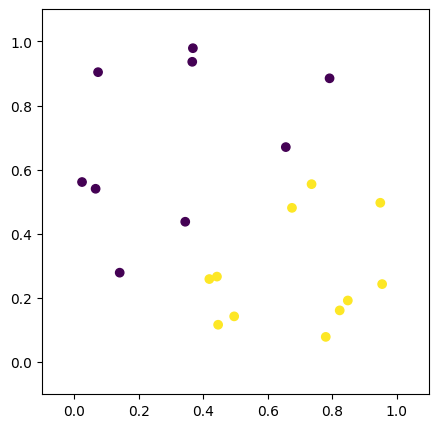

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20, coef=0.5, intercept=0.2):
  X = np.random.rand(n,2)
  y = np.array(X[:,0]*coef>(X[:,1]-intercept), dtype=int)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

plotDataset(X, y)
plt.show()

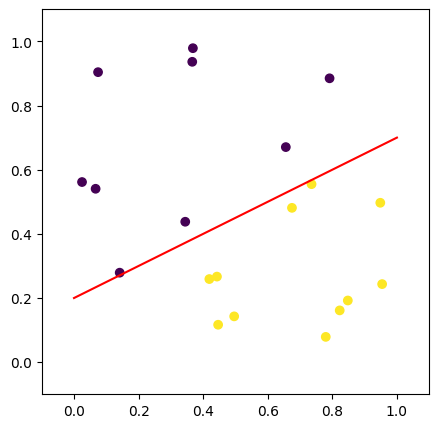

In [2]:
def plotHyperplan(vector, intercept=0):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, 'r-')

plotDataset(X, y)
plotHyperplan(np.array([0.5,-1]), 0.2)
plt.show()


Accuracy: 1.0
Weights: [ 0.21545715  1.59397162 -2.05581967]


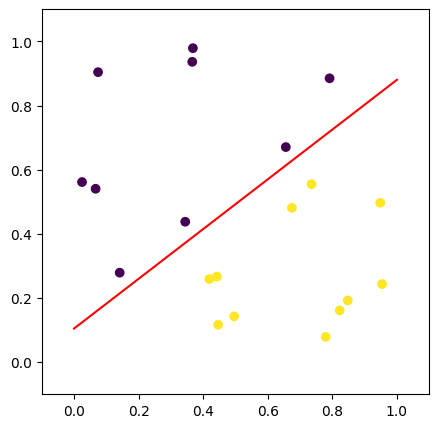

In [7]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

class LinearMachine(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = np.linalg.pinv(X) @ y
    return self
  def predict(self, X):
    X = include_bias(X)
    return np.sign(X @ self.w_)

clf = LinearMachine()
clf.fit(X, y)
ypred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {clf.w_}")
plotDataset(X, y)
plotHyperplan(clf.w_[1:], clf.w_[0])
plt.show()

Accuracy: 0.944


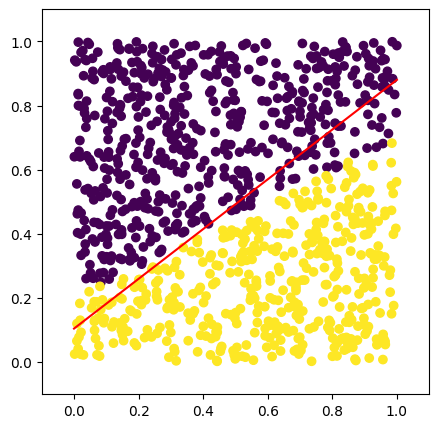

In [6]:
X_test, y_test = createDataset(1000)
ypred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, ypred))
plotDataset(X_test, y_test)
plotHyperplan(clf.w_[1:], clf.w_[0])
plt.show()

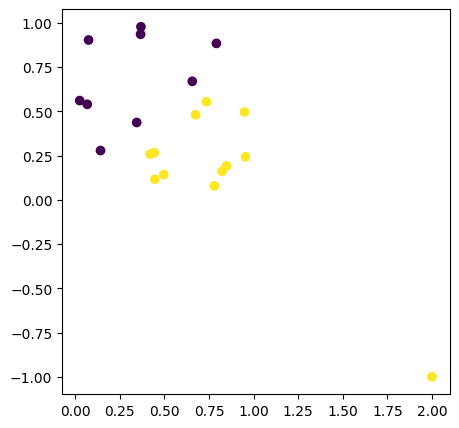

In [8]:
X_outlier = np.concatenate((np.array([[2, -1]]), X))
y_outlier = np.concatenate((np.array([1]), y))
plt.figure(figsize=(5,5))
plt.scatter(X_outlier[:,0], X_outlier[:,1], c=y_outlier)
plt.show()

Accuracy: 1.0
Weights: [ 0.61165715 -1.04325132], 0.18840956397286973


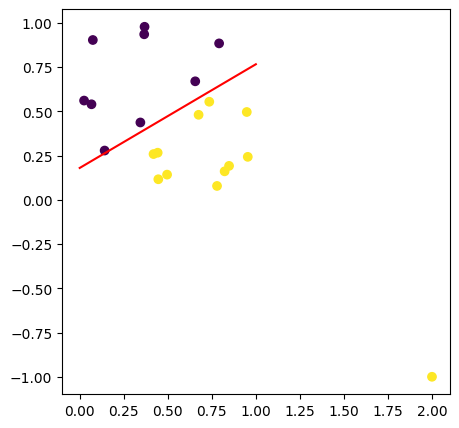

In [14]:
clf = LinearMachine()
clf.fit(X_outlier, y_outlier)
ypred = clf.predict(X_outlier)
print(f"Accuracy: {accuracy_score(y_outlier, ypred)}")
print(f"Weights: {clf.w_[1:]}, {clf.w_[0]}")
plt.figure(figsize=(5,5))
plt.scatter(X_outlier[:,0], X_outlier[:,1], c=y_outlier)
plotHyperplan(clf.w_[1:], clf.w_[0])
plt.show()